# **OCCUPANCY SENSING SYSTEM**


>By : Ashish Kumar



=============================================================================================

In [7]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

print("All libraries imported successfully.")

All libraries imported successfully.


In [8]:
df = pd.read_csv("Occupancy.csv")

# Preview
df.head(3)

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,23.700,26.272,585.200000,749.200000,0.004764,1
1,23.718,26.290,578.400000,760.400000,0.004773,1
2,23.730,26.230,572.666667,769.666667,0.004765,1


# 5. Feature Selection

👉 Features (input variables) and target (output)

In [9]:
X = df.drop("Occupancy", axis=1)   # Features  # AXIS=1 means collumns wise and inside this label means , it will exclude lable(y part)
y = df["Occupancy"]                # Target
print(X)                                          # if print(y) , then it will only print y

       Temperature  Humidity       Light          CO2  HumidityRatio
0          23.7000   26.2720  585.200000   749.200000       0.004764
1          23.7180   26.2900  578.400000   760.400000       0.004773
2          23.7300   26.2300  572.666667   769.666667       0.004765
3          23.7225   26.1250  493.750000   774.750000       0.004744
4          23.7540   26.2000  488.600000   779.000000       0.004767
...            ...       ...         ...          ...            ...
20555      20.8150   27.7175  429.750000  1505.250000       0.004213
20556      20.8650   27.7450  423.500000  1514.500000       0.004230
20557      20.8900   27.7450  423.500000  1521.500000       0.004237
20558      20.8900   28.0225  418.750000  1632.000000       0.004279
20559      21.0000   28.1000  409.000000  1864.000000       0.004321

[20560 rows x 5 columns]


# 6. Encode Target Labels

In [10]:
le = LabelEncoder()                           # har ek lable value(text) ko numerical value me encode kar dega
y_encoded = le.fit_transform(y)
print(y_encoded)



print("\nTarget encoded. Class mapping (sample):")
for crop, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {crop} → {code}")

[1 1 1 ... 1 1 1]

Target encoded. Class mapping (sample):
  0 → 0
  1 → 1


# 7. Train-Test Split

In [11]:
# # 80-20 split, stratified to maintain class balance

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y     # stratify=y , means it will select data for training from whole data set randomly and finally select 80 % of them random , not in  series
)                                                                             #, data will be taken from all the classes

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")
print(f"Features used  : {X_train.shape[1]}")
print(f"\nClass balance in training set:")
unique, counts = np.unique(y_train, return_counts=True)
print(f"  All classes have {counts[0]} samples each — perfectly balanced")

Training set   : 16448 samples
Test set       : 4112 samples
Features used  : 5

Class balance in training set:
  All classes have 12648 samples each — perfectly balanced


#  Model 1 — Decision Tree

Rule-based splits

In [12]:
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt)*100)


Decision Tree Accuracy: 99.14883268482491


#  Model 2 — K-Nearest Neighbors (KNN)



*   Distance-based majority voting




In [13]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn)*100)


KNN Accuracy: 98.97859922178989


# Model 3 — Random Forest Model

Random Forest = Many Decision Trees

Each tree gives a prediction

Final output = majority voting

In [14]:
# Create model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf)*100)


Random Forest Accuracy: 99.24610894941634


# 10. Feature Importance

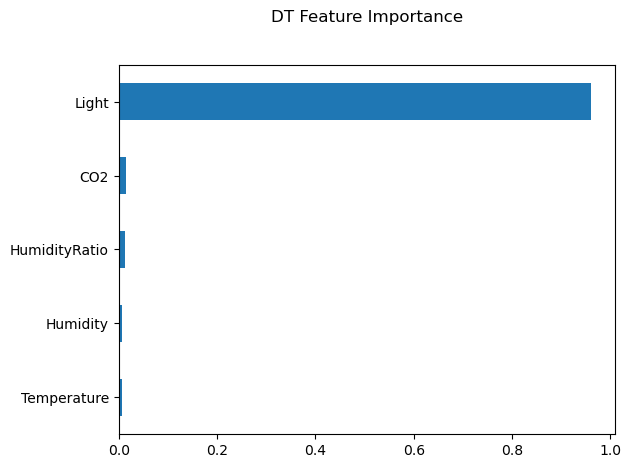

In [15]:
# For DT Model

importances = dt_model.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)
feature_importance.sort_values().plot(kind='barh')

plt.title("DT Feature Importance\n\n")
plt.show()

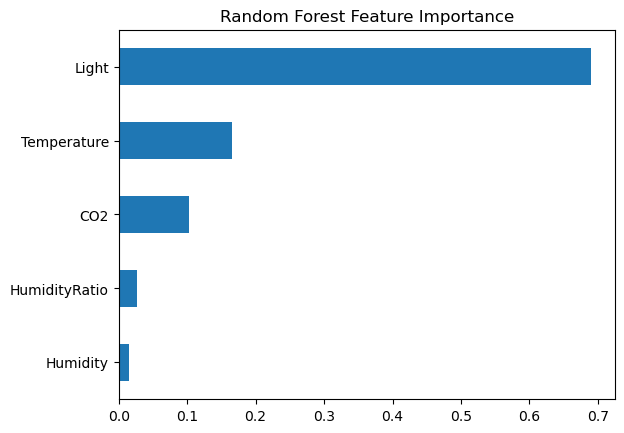

In [16]:
# For RF Model

importances = rf_model.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)
feature_importance.sort_values().plot(kind='barh')

plt.title("Random Forest Feature Importance")
plt.show()

# 11. Sample Prediction (Real-Life Use)

In [17]:
# Example input: [Temperature, Humidity, Light, CO2, humidityRatio]

sample_df = pd.DataFrame(
    [[25, 25, 450, 800, 0.0040]],
    columns=X.columns
)

prediction_dt = dt_model.predict(sample_df)
prediction_knn = knn_model.predict(sample_df)
prediction_rf = rf_model.predict(sample_df)

# Convert back to Occupancy(0,1)
print("Occupancy (DT Model): ", le.inverse_transform(prediction_dt))
print("Occupancy (KNN-Model): ", le.inverse_transform(prediction_knn))
print("Occupancy (RF-Model): ", le.inverse_transform(prediction_rf))

Occupancy (DT Model):  [0]
Occupancy (KNN-Model):  [1]
Occupancy (RF-Model):  [1]


=========================================================================================================

# **UI CREATION USING STREAMLIT**


---


> NAME : **Ashish Kumar**





In [18]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_csv("Occupancy.csv")

# Features & target
X = df.drop("Occupancy", axis=1)
y = df["Occupancy"]

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# Train models
dt = DecisionTreeClassifier().fit(X_train, y_train)
knn = KNeighborsClassifier().fit(X_train, y_train)
rf = RandomForestClassifier().fit(X_train, y_train)

# Save models + encoder
pickle.dump(dt, open("dt_model.pkl", "wb"))
pickle.dump(knn, open("knn_model.pkl", "wb"))
pickle.dump(rf, open("rf_model.pkl", "wb"))
pickle.dump(le, open("label_encoder.pkl", "wb"))

print("Models saved successfully!")

Models saved successfully!


In [19]:
# Install requirements

!pip install -q streamlit
!npm install -g localtunnel


changed 22 packages in 3s

3 packages are looking for funding
  run `npm fund` for details


In [1]:
# Run the app in the background and open the tunnel

!streamlit run appX.py & npx localtunnel --port 8501

^C




---



# 📊 **Data Visualization using Python**
#**=============OCCUPANCY GRAPHICS================**


> Ashish Kumar


In [21]:
# Run this cell first — always!
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# This makes plots appear inside the notebook
%matplotlib inline

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


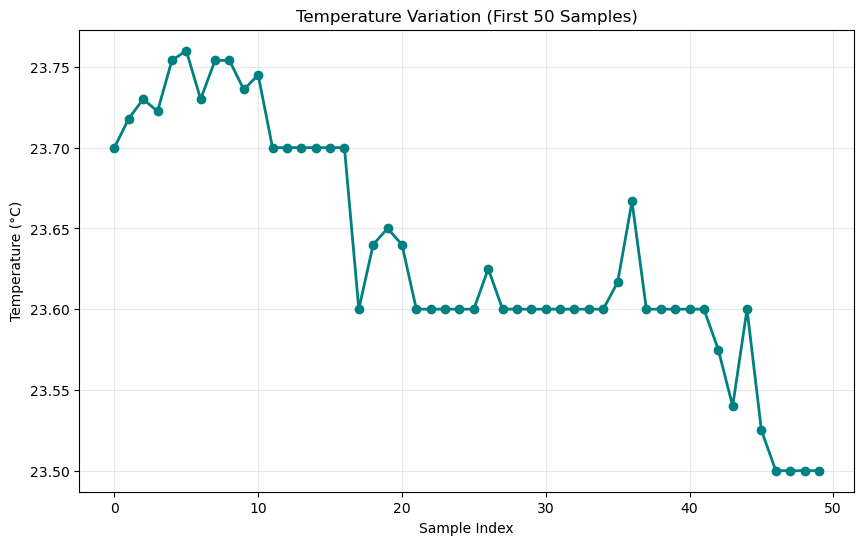

In [22]:
# Example 1: Line Plot - Temperature variation for first 50 samples

df = pd.read_csv('Occupancy.csv')
plt.figure(figsize=(10, 6))
plt.plot(df['Temperature'][:50], marker='o', linestyle='-', color='teal', linewidth=2)
plt.title('Temperature Variation (First 50 Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()

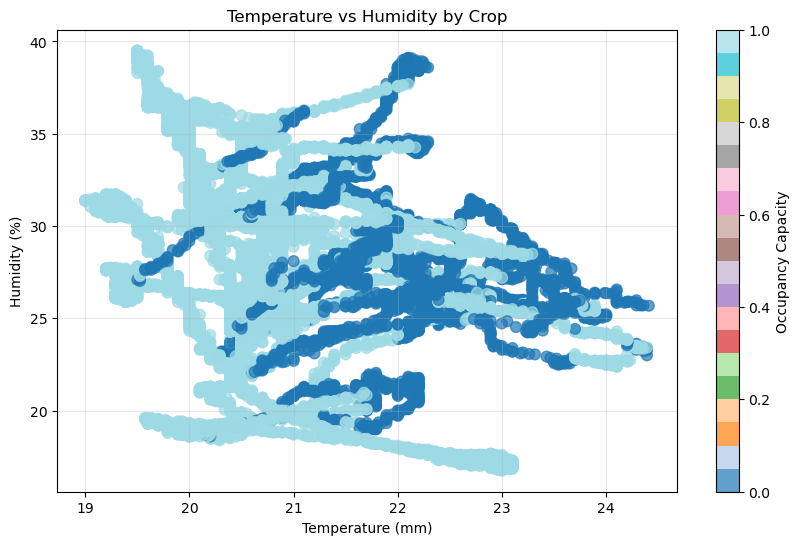

In [23]:
# Example 2: Scatter Plot - Temperature vs Humidity colored by Occupancy

plt.figure(figsize=(10, 6))
plt.scatter(df['Temperature'], df['Humidity'],
            c=pd.factorize(df['Occupancy'])[0],
            cmap='tab20', alpha=0.7, s=60)
plt.title('Temperature vs Humidity by Crop')
plt.xlabel('Temperature (mm)')
plt.ylabel('Humidity (%)')
plt.colorbar(label='Occupancy Capacity')
plt.grid(True, alpha=0.3)
plt.show()

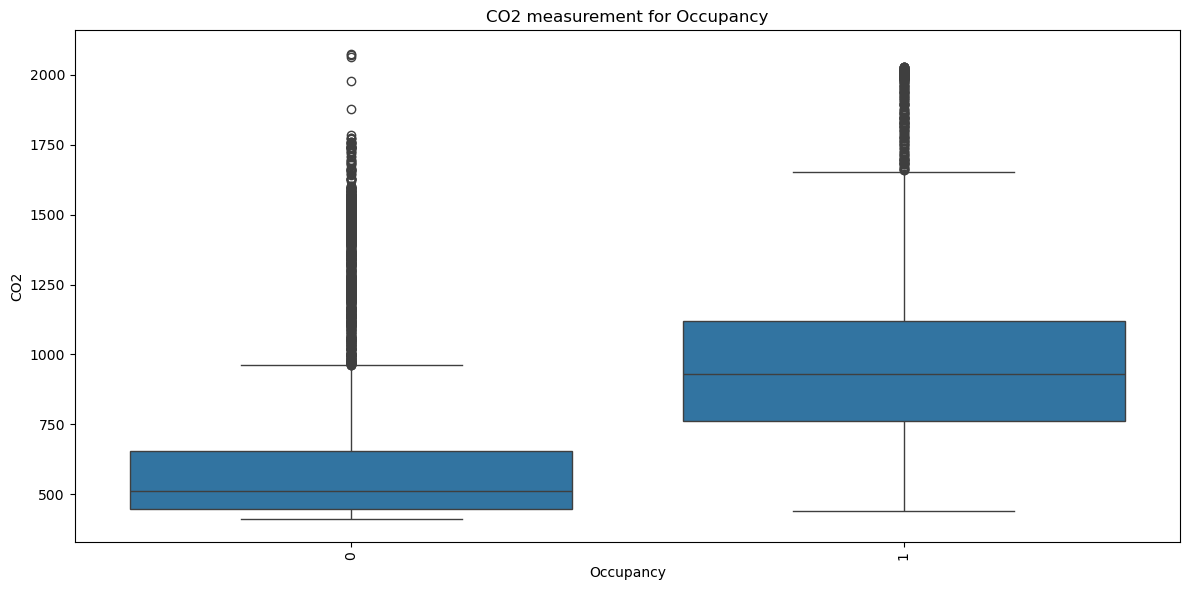

In [24]:
# Example 3: Box Plot - pH distribution across different crops

df = pd.read_csv('Occupancy.csv')

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Occupancy', y='CO2')
plt.title('CO2 measurement for Occupancy')
plt.xlabel('Occupancy')
plt.ylabel('CO2')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

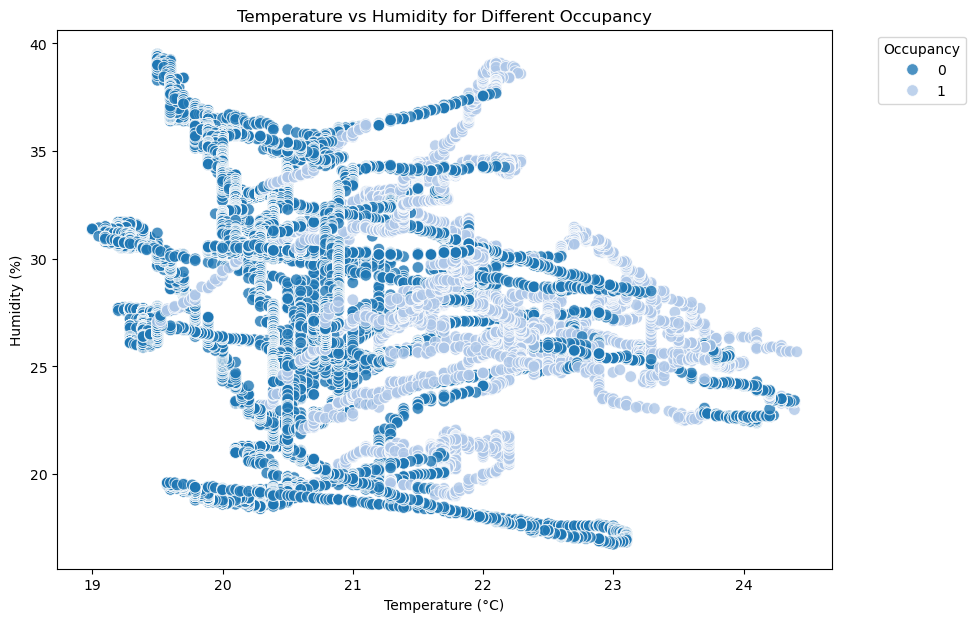

In [25]:
# Example 5: Scatter Plot with Hue (Best for understanding relationships)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Temperature', y='Humidity',
                hue='Occupancy', palette='tab20', alpha=0.8, s=70)
plt.title('Temperature vs Humidity for Different Occupancy')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.legend(title='Occupancy', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()